In [1]:
here::i_am("rna_atac/footprinting/footprinting.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(ArchR))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))


BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

addArchRThreads(24)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/code


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
        

In [1]:
tmp = readRDS('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Kats_atlas/archr/lklsk_both/Save-ArchR-Project.rds')


In [7]:
tmp@projectMetadata$outputDirectory

[1] "/rds/project/rds-SDzz0CATGms/users/vs401/2022.09.Niki.mouse.multiome/ANALYSIS/archr/ArchRSubset"

In [2]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_mofa_clusters.txt.gz')
args$d45_annotations =  file.path(io$basedir, 'results/rna_atac/clustering/d45_celltypes.txt.gz')
args$early_annotations =  file.path(io$basedir, 'results/rna_atac/clustering/early_celltypes.txt.gz')

args$MOFA_factors = file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/mofa/MOFA_factors.txt.gz')
args$MOFA_umap = file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/mofa/MOFA_umap.txt.gz')

# RNA_sce
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')

args$logFC_thr = 0.25
args$FDR_thr = 0.05

# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/differential/v2/expression/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [3]:
# Load meta
meta = fread(args$metadata)[day!='D2.5']

early_annotations = fread(args$early_annotations)
d45_annotations = fread(args$d45_annotations)

In [4]:
head(d45_annotations)

cell,celltype_manual
<chr>,<chr>
RBG43477#AAACAGCCAACACCTA-1,Ectoderm-like
RBG43477#AAACAGCCAATGAAGC-1,Somitic Mesoderm
RBG43477#AAACAGCCAGCATTAT-1,Paraxial Mesoderm
RBG43477#AAACAGCCAGGAAGCC-1,Ectoderm-like
RBG43477#AAACAGCCATGGAGGC-1,Somitic Mesoderm
RBG43477#AAACATGCAAGTAAGC-1,Somitic Mesoderm


In [5]:
meta$celltype_manual = ifelse(meta$day == 'D3', 
                              early_annotations[match(meta$cell, cell), celltype_manual],
                              d45_annotations[match(meta$cell, cell), celltype_manual])

In [6]:
factors = fread(args$MOFA_factors)[cell %in% meta[day == 'D3', cell]]
factors.mtx = factors %>% 
    as.data.frame(.) %>% 
    tibble::column_to_rownames('cell') %>%
    as.matrix()

In [7]:
meta = fread(args$metadata)
meta = meta[day == 'D3']
meta$celltype_manual = ifelse(meta$day == 'D3', 
                              early_annotations[match(meta$cell, cell), celltype_manual],
                              d45_annotations[match(meta$cell, cell), celltype_manual])

meta = meta[!celltype_manual %in% c('Epiblast', 'unknown')]
factors.mtx = factors.mtx[meta$cell,]

In [8]:
neighbors = BiocNeighbors::findKNN(factors.mtx, 100, BPPARAM = BPPARAM)

In [9]:
day_props = meta %>% copy() %>%
    .[,Ntot := .N, by = c('day', 'genotype')] %>% 
    .[,c('day', 'genotype', 'Ntot')] %>% 
    dcast(day~genotype, value.var = 'Ntot') %>% 
    .[,ratio := Eomes_KO/(Eomes_KO+WT)]

id_gt = meta %>% copy() %>% 
    .[,c('genotype', 'day')] %>% 
    .[,cell:=.I]

pseudocount = 1
 
DA = mclapply(1:nrow(meta), function(x){ # nrow(meta)
    print(x)
    tmp = data.table(cell = as.vector(neighbors$index[x,])) %>% 
        merge(., id_gt, by = 'cell')
    
    tmp1 = tmp %>% copy() %>% .[,N := .N, by = 'day'] %>% unique(by = 'day') %>% 
        merge(., day_props[,c('day', 'ratio')], by = 'day') %>% 
        .[, N_ratio := ratio * N]
    
    global_ratio = sum(tmp1$N_ratio)/sum(tmp1$N)

    pvalue = binom.test(nrow(tmp[genotype == 'Eomes_KO']), nrow(tmp), p = global_ratio,
           alternative = "two.sided",
           conf.level = 0.95)$p.value

    tmp2 = data.table(cell = x,
                     # ratio = log2((nrow(tmp[genotype == 'KO']) + pseudocount) / (nrow(tmp[genotype == 'WT']) + pseudocount)),
                      ratio = nrow(tmp[genotype == 'Eomes_KO']) / (nrow(tmp[genotype == 'Eomes_KO']) + nrow(tmp[genotype == 'WT'])),
                      global_ratio = global_ratio,
                      pvalue = pvalue)
}, mc.cores = 16) %>% rbindlist() %>%
    .[,cell := meta$cell]

Aggregate function missing, defaulting to 'length'



In [10]:
meta3 = merge(meta, DA, by = 'cell')

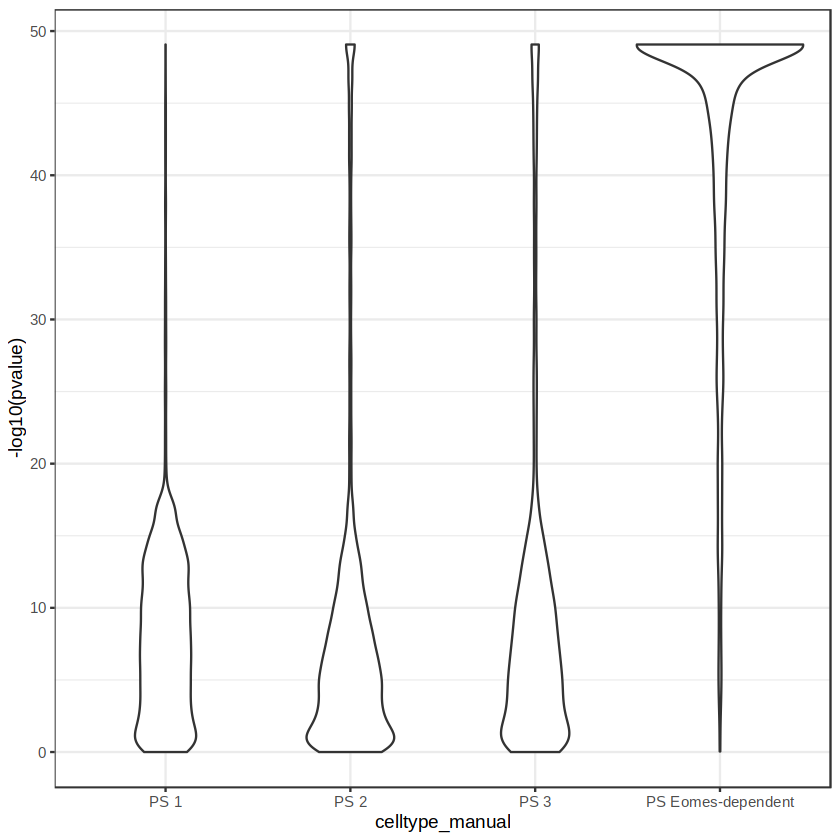

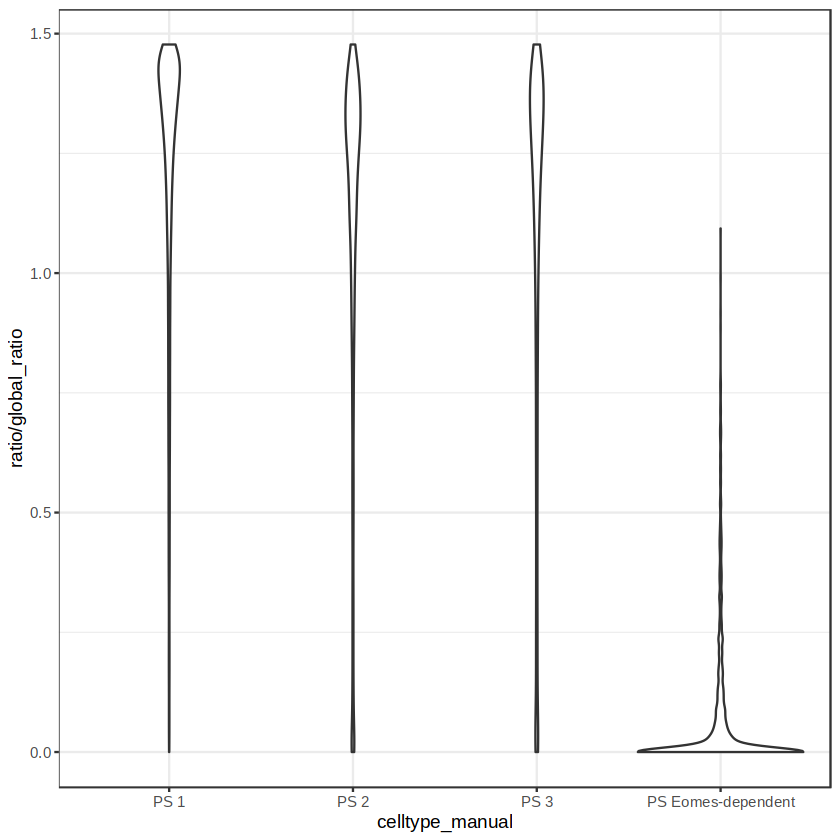

In [11]:
ggplot(meta3, aes(celltype_manual, -log10(pvalue))) + geom_violin() + theme_bw()
ggplot(meta3, aes(celltype_manual, ratio/global_ratio)) + geom_violin() + theme_bw() 

In [12]:
meta3 = meta3[, Eo_depleted := ifelse(pvalue < 1e-20, TRUE, FALSE)]

In [16]:
# Get nearest cells

unique_NN = function(mat, ratio = 1){
    nrcells <- dim(mat)[1]

    # Initialize an empty vector to store unique values
    unique_values <- c()

    # Initialize a logical vector to track processed rows
    processed_rows <- rep(0, nrow(mat))  # Changed to 0 to track the count of unique values per row

    # Loop through each row
    for (row in 1:nrow(mat)) {

      # Go through the columns of the current row
      for (col in 1:ncol(mat)) {

        # Check if we have already taken 2 unique values from this row
        if (processed_rows[row] < ratio) {

          # Get the value from the current cell
          value <- mat[row, col]

          # If the value is not already in the unique_values vector, add it
          if (!value %in% unique_values) {

            unique_values <- c(unique_values, value)
            processed_rows[row] <- processed_rows[row] + 1  # Increment the count of unique values from this row

            # Stop if we have found `2 * nrcells` unique values (since we need 2 per row)
            if (length(unique_values) == ratio * nrcells) {
              break
            }
          }
        }
      }

      # Stop if we already have `ratio * nrcells` unique values
      if (length(unique_values) == ratio * nrcells) {
        break
      }
    }

    # Print the number of rows in the matrix and the length of the unique_values vector
    nrow(mat)
    length(unique_values)
    
    return(unique_values)
    
}

In [17]:
background = factors.mtx[meta3[Eo_depleted != TRUE & 
                            genotype == 'WT',
                      cell],]
query = factors.mtx[meta3[Eo_depleted == TRUE, cell],]

NN = BiocNeighbors::queryKNN(background,
         query = query,
         k = 100)
WT_nearest = rownames(background)[unique_NN(NN$index, ratio = 2)]


In [18]:
background = factors.mtx[meta3[genotype == 'Eomes_KO',
                      cell],]
query = factors.mtx[meta3[Eo_depleted == TRUE, cell],]

NN = BiocNeighbors::queryKNN(background,
         query = query,
         k = 100)

KD_nearest = rownames(background)[unique_NN(NN$index, ratio = 2)]

WT_depleted = meta3[Eo_depleted == TRUE & genotype == 'WT', cell]


In [149]:
meta3 = meta3 %>%
    .[, group := ifelse(cell %in% WT_depleted, 'WT_depleted',
                        ifelse(cell %in% WT_nearest, 'WT_nearest',
                               ifelse(cell %in% KD_nearest, 'KD_nearest',
                                      'Other')))]

mofa_umap = fread(args$MOFA_umap)[match(meta3$cell, cell)]
mofa_umap = merge(meta3, mofa_umap, by = 'cell')

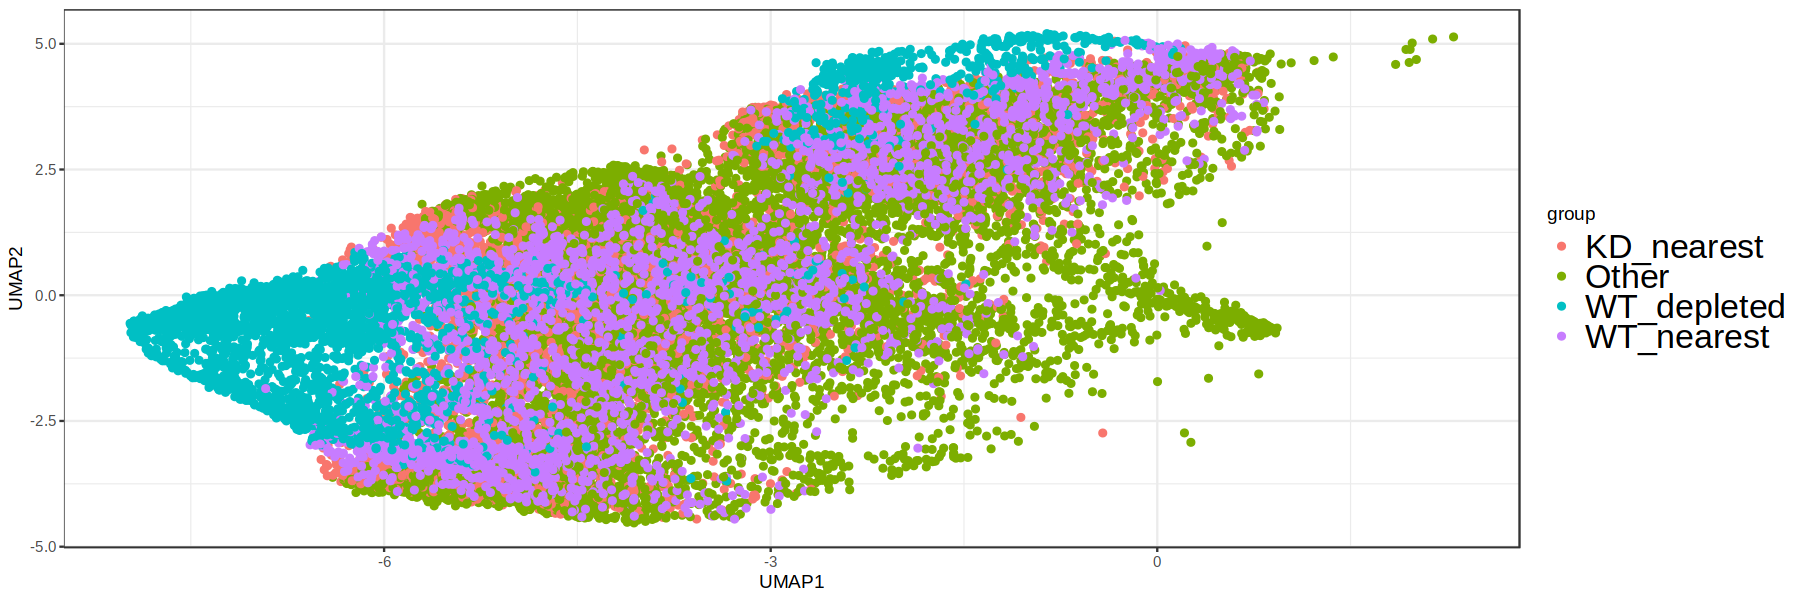

In [154]:
ggplot(mofa_umap[UMAP1 < 2.5], aes(UMAP1, UMAP2, color = group)) + 
    geom_point() +
    theme_bw() + 
    theme(legend.text = element_text(size = 20))

In [144]:
head(meta3)

cell,barcode,sample,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,alias,day,genotype,⋯,nFrags_atac,BlacklistRatio_atac,pass_atacQC,mofa_cluster,celltype_manual,ratio,global_ratio,pvalue,Eo_depleted,group
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<int>,<dbl>,<lgl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>
RBG43473#AAACAGCCAAACGGGC-1,AAACAGCCAAACGGGC-1,RBG43473,3265,7731,18.25,4.32,D3_KO_rep1,D3,Eomes_KO,⋯,31646,0.02,TRUE,6,PS 1,0.94,0.6769147,2.666480e-10,FALSE,Other
RBG43473#AAACAGCCAAATATCC-1,AAACAGCCAAATATCC-1,RBG43473,4251,12278,14.55,3.70,D3_KO_rep1,D3,Eomes_KO,⋯,15220,0.02,TRUE,5,PS 2,0.93,0.6769147,2.291342e-09,FALSE,KD_nearest
RBG43473#AAACAGCCAACAGCCT-1,AAACAGCCAACAGCCT-1,RBG43473,2242,4401,17.70,6.91,D3_KO_rep1,D3,Eomes_KO,⋯,15485,0.02,TRUE,1,PS 2,0.83,0.6769147,8.231603e-04,FALSE,Other
RBG43473#AAACAGCCACAATGTT-1,AAACAGCCACAATGTT-1,RBG43473,3376,8434,16.93,5.56,D3_KO_rep1,D3,Eomes_KO,⋯,19055,0.02,TRUE,14,PS 1,0.96,0.6769147,3.813442e-12,FALSE,Other
RBG43473#AAACAGCCATCCAGGT-1,AAACAGCCATCCAGGT-1,RBG43473,2468,5037,16.62,4.51,D3_KO_rep1,D3,Eomes_KO,⋯,14572,0.02,TRUE,1,PS 2,0.62,0.6769147,2.396224e-01,FALSE,KD_nearest
RBG43473#AAACAGCCATTCAGCA-1,AAACAGCCATTCAGCA-1,RBG43473,3220,7623,14.50,3.11,D3_KO_rep1,D3,Eomes_KO,⋯,5701,0.02,TRUE,4,PS 2,0.97,0.6769147,2.771132e-13,FALSE,Other


In [20]:
table(meta3$group)


 KD_nearest       Other WT_depleted  WT_nearest 
       5155       12154        3274        3389 

In [22]:
ArchRProject = loadArchRProject(io$archR.directory)

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [23]:
ArchRProject = addCellColData(
  ArchRProj = ArchRProject,
  data = meta3$group,
  name = 'Comparison_group',
  cells = meta3$cell)

In [25]:
library(BSgenome.Mmusculus.UCSC.mm10)

Loading required package: BSgenome

Loading required package: rtracklayer

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”


In [27]:
addArchRThreads(42)

Setting default number of Parallel threads to 42.



In [28]:
# Add group coverages
ArchRProject <- addGroupCoverages(ArchRProject, 
  groupBy = "Comparison_group",
  useLabels = TRUE,  # Need to use sample information, otherwise only 50 cells get used per condition. (bug in ArchR)
  minCells = 50,
  maxCells = 10000,
  force = TRUE
)

ArchR logging to : ArchRLogs/ArchR-addGroupCoverages-2e3d645d2c3e95-Date-2024-10-08_Time-11-26-45.log
If there is an issue, please report to github with logFile!

KD_nearest (1 of 4) : CellGroups N = 3

Other (2 of 4) : CellGroups N = 3

WT_depleted (3 of 4) : CellGroups N = 2

WT_nearest (4 of 4) : CellGroups N = 2

2024-10-08 11:26:46 : Further Sampled 7 Groups above the Max Fragments!, 0.021 mins elapsed.

2024-10-08 11:26:46 : Creating Coverage Files!, 0.027 mins elapsed.

2024-10-08 11:26:46 : Batch Execution w/ safelapply!, 0.027 mins elapsed.

2024-10-08 11:27:33 : Adding Kmer Bias to Coverage Files!, 0.813 mins elapsed.

Completed Kmer Bias Calculation

Adding Kmer Bias (1 of 10)

Adding Kmer Bias (2 of 10)

Adding Kmer Bias (3 of 10)

Adding Kmer Bias (4 of 10)

Adding Kmer Bias (5 of 10)

Adding Kmer Bias (6 of 10)

Adding Kmer Bias (7 of 10)

Adding Kmer Bias (8 of 10)

Adding Kmer Bias (9 of 10)

Adding Kmer Bias (10 of 10)

2024-10-08 11:28:00 : Finished Creation of Covera

In [32]:
new_peaks = readRDS('/rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/results/rna_atac/clustering/early_peaks.rds')

In [ ]:
## Get motif matches for example motifs in peaks 
## Adapted from: https://rdrr.io/github/GreenleafLab/ArchR/src/R/AnnotationPeaks.R
# Load motifs
library(motifmatchr)
library(chromVARmotifs)

data("mouse_pwms_v2")
motifs <- mouse_pwms_v2
obj <- ArchR:::.summarizeChromVARMotifs(motifs)
motifs <- obj$motifs
motifSummary <- obj$motifSummary
names(motifs) = gsub( 'Tcfap', 'tfap', names(motifs))

# Find scores
motifmatcher.se <-  motifmatchr::matchMotifs(pwms = motifs, 
                                        subject = new_peaks, 
                                        genome = "mm10", 
                                        out = 'positions',
                                        p.cutoff = 5e-05,
                                        w = 7) 

In [70]:
motifPositions = motifmatcher.se

In [71]:
# motifs of interest
motifs <- c("Eomes", "Lhx1", "Cdx1", "Lhx1", "Gsc", "Zic2", "Zic3", "Lef1", "Tcf7", "Pou5f1", "Bcl11a", 'Sox2', 'Mesp1', 'Mesp2')
#motifs = "Smad1"
markerMotifs <- unlist(lapply(motifs, function(x) grep(x, names(motifPositions), value = TRUE)))
markerMotifs

[1] "Eomes_768"  "Lhx1_422"   "Cdx1_448"   "Lhx1_422"   "Gsc_429"   
 [6] "Gsc2_442"   "Zic2_225"   "Zic3_229"   "Lef1_734"   "Tcf7_726"  
[11] "Tcf7l2_732" "Tcf7l1_744" "Pou5f1_618" "Bcl11a_795" "Sox21_745" 
[16] "Sox2_750"   "Mesp1_58"   "Mesp2_57"

In [72]:
# get footprints
seFoot <- getFootprints(
    ArchRProj = ArchRProject, 
    positions = motifPositions[markerMotifs], 
    groupBy = "Comparison_group",
    flank = 500,
)

ArchR logging to : ArchRLogs/ArchR-getFootprints-2e3d647d982851-Date-2024-10-08_Time-13-31-33.log
If there is an issue, please report to github with logFile!

2024-10-08 13:31:33 : Computing Kmer Bias Table, 0.002 mins elapsed.

2024-10-08 13:32:04 : Finished Computing Kmer Tables, 0.529 mins elapsed.

2024-10-08 13:32:04 : Computing Footprints, 0.531 mins elapsed.

2024-10-08 13:32:11 : Computing Footprints Bias, 0.633 mins elapsed.

2024-10-08 13:32:13 : Summarizing Footprints, 0.67 mins elapsed.



In [73]:
plotFootprints(
      seFoot = seFoot,
      ArchRProj = ArchRProject, 
      normMethod = "Subtract",
      plotName = paste0('Footprints_motifs'),
      addDOC = FALSE,
      smoothWindow = 15
)

ArchR logging to : ArchRLogs/ArchR-plotFootprints-2e3d645cd54565-Date-2024-10-08_Time-13-32-14.log
If there is an issue, please report to github with logFile!

2024-10-08 13:32:14 : Plotting Footprint : Eomes_768 (1 of 18), 0.001 mins elapsed.

Applying smoothing window to footprint

Normalizing by flanking regions

NormMethod = Subtract

2024-10-08 13:32:15 : Plotting Footprint : Lhx1_422 (2 of 18), 0.014 mins elapsed.

Applying smoothing window to footprint

Normalizing by flanking regions

NormMethod = Subtract

2024-10-08 13:32:16 : Plotting Footprint : Cdx1_448 (3 of 18), 0.026 mins elapsed.

Applying smoothing window to footprint

Normalizing by flanking regions

NormMethod = Subtract

2024-10-08 13:32:16 : Plotting Footprint : Lhx1_422 (4 of 18), 0.039 mins elapsed.

Applying smoothing window to footprint

Normalizing by flanking regions

NormMethod = Subtract

2024-10-08 13:32:17 : Plotting Footprint : Gsc_429 (5 of 18), 0.052 mins elapsed.

Applying smoothing window to footpri

# Silico ChIP

In [74]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/code/rna_atac/footprinting"

In [75]:
io$multiome = '/rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/results/multiome_atlas/'
silicoChIP = readRDS(file.path(io$multiome, 'vitro_peaks_silicoChIP_cisbp_earlyPeaks.rds'))

In [76]:
silico = lapply(1:length(motifs), function(i){
    print(motifs[i])
    keep_peaks = as.data.table(as.matrix((assay(silicoChIP[, toupper(motifs[i])], 'VirtualChipScores'))), keep.rownames=T) %>% 
        setnames(c('peak', 'score')) %>%
        .[score>0.15] %>%
        .[, chr:=str_split(peak, ':') %>% map_chr(1)] %>%
        .[, start:=str_split(str_split(peak, ':') %>% map_chr(2), '-') %>% map_chr(1)] %>%
        .[, end:=str_split(str_split(peak, ':') %>% map_chr(2), '-') %>% map_chr(2)] 
    overlap = findOverlaps(makeGRangesFromDataFrame(keep_peaks), motifPositions[[markerMotifs[i]]])
    silico = motifPositions[[markerMotifs[i]]][subjectHits(overlap)]
    return(silico)
})
names(silico) = motifs

[1] "Eomes"
[1] "Lhx1"
[1] "Cdx1"
[1] "Lhx1"
[1] "Gsc"
[1] "Zic2"
[1] "Zic3"
[1] "Lef1"
[1] "Tcf7"
[1] "Pou5f1"
[1] "Bcl11a"
[1] "Sox2"
[1] "Mesp1"
[1] "Mesp2"


In [83]:
seFoot_silico <- getFootprints(
  ArchRProj = ArchRProject, 
  positions = silico, 
  groupBy = "Comparison_group",
    flank = 500
)

ArchR logging to : ArchRLogs/ArchR-getFootprints-2e3d647f701045-Date-2024-10-08_Time-13-35-26.log
If there is an issue, please report to github with logFile!

2024-10-08 13:35:26 : Computing Kmer Bias Table, 0.002 mins elapsed.

2024-10-08 13:35:31 : Finished Computing Kmer Tables, 0.092 mins elapsed.

2024-10-08 13:35:31 : Computing Footprints, 0.094 mins elapsed.

2024-10-08 13:35:36 : Computing Footprints Bias, 0.177 mins elapsed.

2024-10-08 13:35:38 : Summarizing Footprints, 0.208 mins elapsed.



In [84]:
plotFootprints(
      seFoot = seFoot_silico,
      ArchRProj = ArchRProject, 
      normMethod = "Subtract",
      plotName = paste0('Footprints_silico'),
      addDOC = FALSE,
      smoothWindow = 15
)

ArchR logging to : ArchRLogs/ArchR-plotFootprints-2e3d641d4ea276-Date-2024-10-08_Time-13-35-39.log
If there is an issue, please report to github with logFile!

2024-10-08 13:35:39 : Plotting Footprint : Eomes (1 of 14), 0.001 mins elapsed.

Applying smoothing window to footprint

Normalizing by flanking regions

NormMethod = Subtract

2024-10-08 13:35:40 : Plotting Footprint : Lhx1 (2 of 14), 0.013 mins elapsed.

Applying smoothing window to footprint

Normalizing by flanking regions

NormMethod = Subtract

2024-10-08 13:35:41 : Plotting Footprint : Cdx1 (3 of 14), 0.026 mins elapsed.

Applying smoothing window to footprint

Normalizing by flanking regions

NormMethod = Subtract

2024-10-08 13:35:42 : Plotting Footprint : Lhx1 (4 of 14), 0.039 mins elapsed.

Applying smoothing window to footprint

Normalizing by flanking regions

NormMethod = Subtract

2024-10-08 13:35:42 : Plotting Footprint : Gsc (5 of 14), 0.052 mins elapsed.

Applying smoothing window to footprint

Normalizing by f

#### Negative

In [85]:
silico = mclapply(1:length(motifs), function(i){
    keep_peaks = as.data.table(as.matrix((assay(silicoChIP[, toupper(motifs[i])], 'VirtualChipScores'))), keep.rownames=T) %>% 
        setnames(c('peak', 'score')) %>%
        .[score <= -0.10] %>%
        .[, chr:=str_split(peak, ':') %>% map_chr(1)] %>%
        .[, start:=str_split(str_split(peak, ':') %>% map_chr(2), '-') %>% map_chr(1)] %>%
        .[, end:=str_split(str_split(peak, ':') %>% map_chr(2), '-') %>% map_chr(2)] 
    overlap = findOverlaps(makeGRangesFromDataFrame(keep_peaks), motifPositions[[markerMotifs[i]]])
    silico = motifPositions[[markerMotifs[i]]][subjectHits(overlap)]
    return(silico)
})
names(silico) = motifs

In [86]:
seFoot_silico <- getFootprints(
  ArchRProj = ArchRProject, 
  positions = silico, 
  groupBy = "Comparison_group",
    flank = 500
)

ArchR logging to : ArchRLogs/ArchR-getFootprints-2e3d645807d0d2-Date-2024-10-08_Time-13-35-52.log
If there is an issue, please report to github with logFile!

2024-10-08 13:35:52 : Computing Kmer Bias Table, 0.002 mins elapsed.

2024-10-08 13:35:58 : Finished Computing Kmer Tables, 0.101 mins elapsed.

2024-10-08 13:35:58 : Computing Footprints, 0.103 mins elapsed.

2024-10-08 13:36:03 : Computing Footprints Bias, 0.176 mins elapsed.

2024-10-08 13:36:05 : Summarizing Footprints, 0.21 mins elapsed.



In [87]:
plotFootprints(
      seFoot = seFoot_silico,
      ArchRProj = ArchRProject, 
      normMethod = "Subtract",
      plotName = paste0('Footprints_silico_neg'),
      addDOC = FALSE,
      smoothWindow = 15
)

ArchR logging to : ArchRLogs/ArchR-plotFootprints-2e3d64720e48db-Date-2024-10-08_Time-13-36-06.log
If there is an issue, please report to github with logFile!

2024-10-08 13:36:06 : Plotting Footprint : Eomes (1 of 14), 0.001 mins elapsed.

Applying smoothing window to footprint

Normalizing by flanking regions

NormMethod = Subtract

2024-10-08 13:36:07 : Plotting Footprint : Lhx1 (2 of 14), 0.013 mins elapsed.

Applying smoothing window to footprint

Normalizing by flanking regions

NormMethod = Subtract

2024-10-08 13:36:08 : Plotting Footprint : Cdx1 (3 of 14), 0.026 mins elapsed.

Applying smoothing window to footprint

Normalizing by flanking regions

NormMethod = Subtract

2024-10-08 13:36:08 : Plotting Footprint : Lhx1 (4 of 14), 0.039 mins elapsed.

Applying smoothing window to footprint

Normalizing by flanking regions

NormMethod = Subtract

2024-10-08 13:36:09 : Plotting Footprint : Gsc (5 of 14), 0.052 mins elapsed.

Applying smoothing window to footprint

Normalizing by f

# ChIP-peak centres Zfp462

In [88]:
zfp462 = fread('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/ChIP/zfp462/Ramesh/ZFP462_BioChIp_summits.bed')

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”


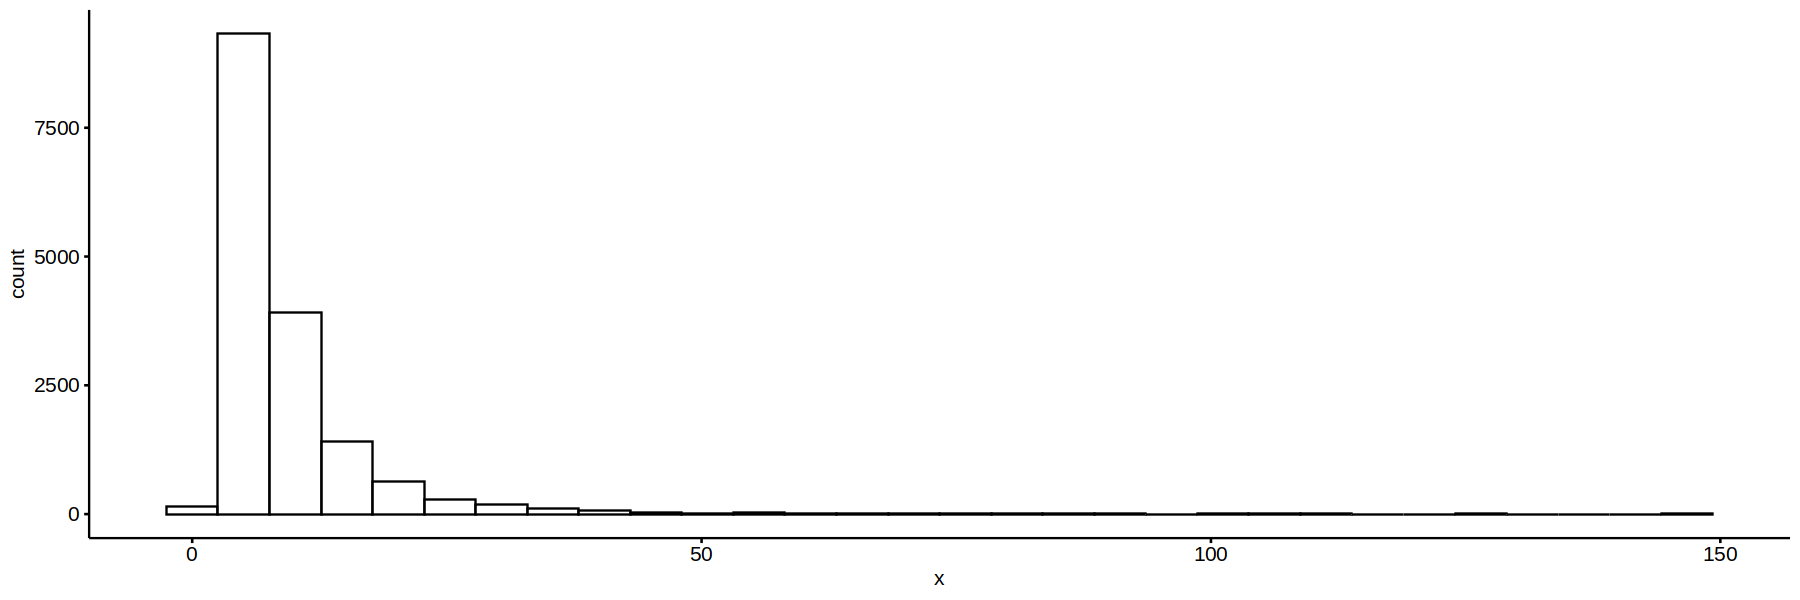

In [89]:
options(repr.plot.width=15, repr.plot.height=5)
gghistogram(zfp462[V5<150]$V5)

In [90]:
nrow(zfp462)

[1] 16264

In [91]:
zfp462.gr = makeGRangesFromDataFrame(zfp462[order(-V5)][V5>0][,c(1,2,3)] %>% 
                                         setnames(c('chr', 'start', 'end')) %>% 
                                        .[chr %in% paste0('chr', c(1:19, 'X'))] %>% head(3000))
zfp462.gr = GRangesList(zfp462.gr)
names(zfp462.gr) = 'Zfp462'

seFoot_zfp <- getFootprints(
  ArchRProj = ArchRProject, 
  positions = zfp462.gr, 
  groupBy = "Comparison_group"
)

ArchR logging to : ArchRLogs/ArchR-getFootprints-2e3d643c47385b-Date-2024-10-08_Time-13-37-51.log
If there is an issue, please report to github with logFile!

2024-10-08 13:37:51 : Computing Kmer Bias Table, 0.002 mins elapsed.

2024-10-08 13:37:55 : Finished Computing Kmer Tables, 0.066 mins elapsed.

2024-10-08 13:37:55 : Computing Footprints, 0.068 mins elapsed.

2024-10-08 13:38:00 : Computing Footprints Bias, 0.146 mins elapsed.

2024-10-08 13:38:01 : Summarizing Footprints, 0.175 mins elapsed.



In [92]:
plotFootprints(
  seFoot = seFoot_zfp,
  ArchRProj = ArchRProject, 
  normMethod = "subtract",
  plotName = paste0('Footprints_Zfp462_top3000'),
  addDOC = FALSE,
  smoothWindow = 10
)

ArchR logging to : ArchRLogs/ArchR-plotFootprints-2e3d641c1035d6-Date-2024-10-08_Time-13-38-13.log
If there is an issue, please report to github with logFile!

2024-10-08 13:38:13 : Plotting Footprint : Zfp462 (1 of 1), 0.001 mins elapsed.

Applying smoothing window to footprint

Normalizing by flanking regions

NormMethod = subtract

ArchR logging successful to : ArchRLogs/ArchR-plotFootprints-2e3d641c1035d6-Date-2024-10-08_Time-13-38-13.log



In [97]:
zfp462.gr = makeGRangesFromDataFrame(zfp462[order(-V5)][V5>0][,c(1,2,3)] %>% 
                                         setnames(c('chr', 'start', 'end')) %>% 
                                        .[chr %in% paste0('chr', c(1:19, 'X'))] %>% head(1000))
zfp462.gr = GRangesList(zfp462.gr)
names(zfp462.gr) = 'Zfp462'

seFoot_zfp <- getFootprints(
  ArchRProj = ArchRProject, 
  positions = zfp462.gr, 
  groupBy = "Comparison_group",
  flank = 2000 
)

plotFootprints(
      seFoot = seFoot_zfp,
      ArchRProj = ArchRProject, 
      normMethod = "subtract",
      plotName = paste0('Footprints_Zfp462_top3000_2kbFlank'),
      addDOC = FALSE,
      smoothWindow = 20
)

ArchR logging to : ArchRLogs/ArchR-getFootprints-2e3d64162b692d-Date-2024-10-08_Time-13-40-21.log
If there is an issue, please report to github with logFile!

2024-10-08 13:40:21 : Computing Kmer Bias Table, 0.002 mins elapsed.

2024-10-08 13:40:22 : Finished Computing Kmer Tables, 0.008 mins elapsed.

2024-10-08 13:40:22 : Computing Footprints, 0.01 mins elapsed.

2024-10-08 13:40:25 : Computing Footprints Bias, 0.073 mins elapsed.

2024-10-08 13:40:27 : Summarizing Footprints, 0.105 mins elapsed.

ArchR logging to : ArchRLogs/ArchR-plotFootprints-2e3d64460552f8-Date-2024-10-08_Time-13-40-28.log
If there is an issue, please report to github with logFile!

2024-10-08 13:40:28 : Plotting Footprint : Zfp462 (1 of 1), 0.001 mins elapsed.

Applying smoothing window to footprint

Normalizing by flanking regions

NormMethod = subtract

ArchR logging successful to : ArchRLogs/ArchR-plotFootprints-2e3d64460552f8-Date-2024-10-08_Time-13-40-28.log

